In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [2]:
# Read in cleaned dataset
X_with_urn = pd.read_csv('./model_data/final_features.csv') 
y = pd.read_csv('./model_data/labels.csv')  # 1 = target, 0 = non-target

entity_urns = X_with_urn['entity_urn'].copy()

X = X_with_urn.drop(columns=['entity_urn'])

## Train / Val / Test split

In [3]:
# Separate targets and non-targets
targets = X[y.values == 1]   
non_targets = X[y.values == 0]  

In [4]:
# Split targets into Train/Val/Test manually
targets_train, targets_temp = train_test_split(
    targets, test_size=0.4, random_state=42
)
targets_val, targets_test = train_test_split(
    targets_temp, test_size=0.5, random_state=42
)

# Now split non-targets similarly
non_targets_train, non_targets_temp = train_test_split(
    non_targets, test_size=0.4, random_state=42
)
non_targets_val, non_targets_test = train_test_split(
    non_targets_temp, test_size=0.5, random_state=42
)

In [5]:
# Aggressively undersample non-targets (5x more non-targets than targets)
non_targets_train = resample(
    non_targets_train,
    replace=False,
    n_samples=len(targets_train) * 5,  # Adjust ratio here (5x, 10x etc.)
    random_state=42
)

In [6]:
# Combine targets and non-targets back
X_train = pd.concat([targets_train, non_targets_train])
y_train = pd.Series([1]*len(targets_train) + [0]*len(non_targets_train))

X_val = pd.concat([targets_val, non_targets_val])
y_val = pd.Series([1]*len(targets_val) + [0]*len(non_targets_val))

X_test = pd.concat([targets_test, non_targets_test])
y_test = pd.Series([1]*len(targets_test) + [0]*len(non_targets_test))

In [7]:
# # Shuffle each set (important so targets aren't clustered at top)
# For Train
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

train_data = X_train.copy()
train_data['label'] = y_train

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_train = train_data['label']
X_train = train_data.drop(columns=['label'])

# # For Validation
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

val_data = X_val.copy()
val_data['label'] = y_val
val_data = val_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_val = val_data['label']
X_val = val_data.drop(columns=['label'])

# # For Test
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

test_data = X_test.copy()
test_data['label'] = y_test
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_test = test_data['label']
X_test = test_data.drop(columns=['label'])

In [8]:
# Check
print("Train targets:", (y_train == 1).sum())
print("Validation targets:", (y_val == 1).sum())
print("Test targets:", (y_test == 1).sum())

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train targets: 36
Validation targets: 12
Test targets: 13
Train size: (216, 33), Validation size: (2976, 33), Test size: (2977, 33)


## Find best hyperparameters

In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',  # again, correct for your case
    n_jobs=-1,
    cv=3,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

# Best Model
print("Best Hyperparameters:", random_search.best_params_)
print(f"Best CV AP Score: {random_search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10

In [10]:
# model with best hyper params
best_rf = random_search.best_estimator_

Validation AP Score (best model): 0.9866


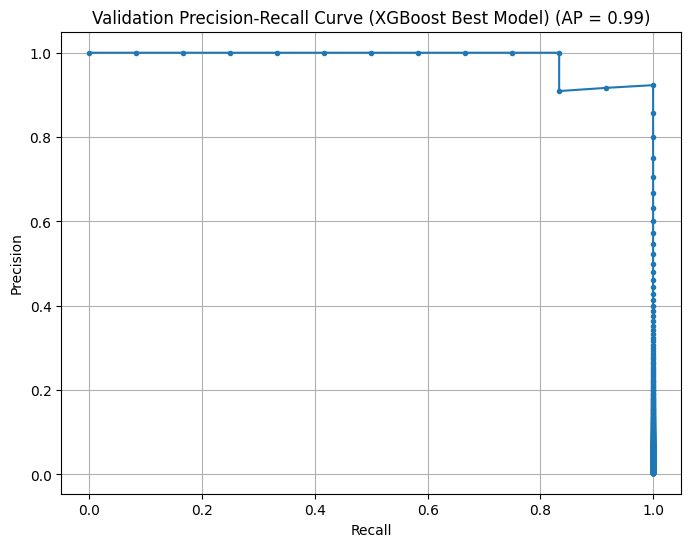

In [11]:
y_val_pred_proba = best_rf.predict_proba(X_val)[:, 1]
ap_val = average_precision_score(y_val, y_val_pred_proba)

print(f"Validation AP Score (best model): {ap_val:.4f}")

# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title(f'Validation Precision-Recall Curve (XGBoost Best Model) (AP = {ap_val:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

## Retrain on Full Training + Validation Set

In [12]:
# Combine training and validation sets
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

# Reinitialize the model with best hyperparameters
final_model = RandomForestClassifier(
    **random_search.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Retrain
final_model.fit(X_final_train, y_final_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=10, n_jobs=-1, random_state=42)

In [13]:
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]
ap_test = average_precision_score(y_test, y_test_pred_proba)

print(f"Test AP Score: {ap_test:.4f}")

Test AP Score: 1.0000


In [14]:
# Predict similarity scores
similarity_scores = final_model.predict_proba(X)[:, 1]

# Attach to company IDs
scored_companies = pd.DataFrame({
    'entity_urn': entity_urns,  # update with your real ID column
    'similarity_score': similarity_scores
})

scored_companies.sort_values(by='similarity_score', ascending=False, inplace=True)

# Save results
scored_companies.to_csv('company_similarity_scores.csv', index=False)


In [15]:
scored_companies

,entity_urn,similarity_score
37,urn:harmonic:company:796251,0.989444
6,urn:harmonic:company:6585,0.988930
39,urn:harmonic:company:773835,0.986378
19,urn:harmonic:company:9609784,0.979949
32,urn:harmonic:company:602158,0.978489
...,...,...
6467,urn:harmonic:company:56296,0.000000
6468,urn:harmonic:company:58087,0.000000
6469,urn:harmonic:company:425122,0.000000
6470,urn:harmonic:company:528205,0.000000


In [16]:
target_company_data = pd.read_parquet('./case_study_data/target_company_data.parquet')
company_data = pd.read_parquet('./case_study_data/company_data.parquet')

company_data = company_data[~company_data['entity_urn'].isin(target_company_data['entity_urn'])]

target_company_data['is_target'] = 1
company_data['is_target'] = 0

company_full = pd.concat([target_company_data, company_data])

In [17]:
company_full = company_full[['entity_urn', 'ownership_status', 'headcount', 'twitter_follower_count', 'linkedin_follower_count', 'funding_total',
                             'funding_stage', 'gpt_sector', 'domain', 'name', 'city', 'country', 'years_since_founding',
                             'investors', 'highlights', 'is_target']]

In [18]:
from cleanco import basename
from urlextract import URLExtract

extractor = URLExtract()

def extract_vc(highlights):
    for item in highlights:
        if item.get('category') == 'Venture Backed' and item.get('text') is not None:
            text = item['text']
            # Remove the "Backed By" prefix
            firms = text.replace('Backed By ', '')
            
            urls = extractor.find_urls(text)
            urls = [url.strip(',') for url in urls]

            firms = firms.split(', ')
            firms = [firm for firm in firms if basename(firm).strip() != '' and firm not in urls]

            # Return number of unique firms
            return firms
    return ''  # No Venture Backed category found

In [19]:
company_full['highlights'] = company_full['highlights'].apply(extract_vc)
company_full = company_full.merge(scored_companies, how="left", on="entity_urn")
company_full.sort_values(by='similarity_score', ascending=False)

,entity_urn,ownership_status,headcount,twitter_follower_count,linkedin_follower_count,funding_total,funding_stage,gpt_sector,domain,name,city,country,years_since_founding,investors,highlights,is_target,similarity_score
37,urn:harmonic:company:796251,PRIVATE,57,77.0,1631,38.00,SERIES_B,Healthcare Software,acuitymd.com,"AcuityMD, Inc.",Boston,United States,5.967123,"[Ajax Health, Benchmark, ICONIQ Capital, Partn...","[Ajax Health, Artisanal Ventures, Atreides Man...",1,0.989444
6,urn:harmonic:company:6585,PRIVATE,40,51.0,2180,31.80,SERIES_B,Data,freshpaint.io,Freshpaint,San Francisco,United States,5.967123,"[Zero Prime Ventures, Intel Capital, Abstracti...","[Abstraction Capital, BT Growth Capital, Intel...",1,0.988930
39,urn:harmonic:company:773835,PRIVATE,23,5153.0,737,6.50,SERIES_B,Infrastructure,clerk.com,Clerk.com,San Francisco,United States,4.802740,"[Darragh Buckley, Mango Capital, Andreessen Ho...","[Andreessen Horowitz, CRV, Darragh Buckley, Da...",1,0.986378
19,urn:harmonic:company:9609784,PRIVATE,36,1437.0,1545,5.00,SEED,Cybersecurity,doppel.com,Doppel,Covina,United States,2.964384,"[The Spartan Group, Quiet Capital, Coinbase, P...","[6529 Capital, Andreessen Horowitz, Andreessen...",1,0.979949
32,urn:harmonic:company:602158,PRIVATE,27,1549.0,1020,11.60,SERIES_B,Cybersecurity,sublime.security,Sublime Security,Washington,United States,5.967123,"[Slow Ventures, Decibel Partners, IVP, Worthi,...","[Decibel, Decibel Partners, Dmitri Alperovitch...",1,0.978489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14669,urn:harmonic:company:4864635,,870,1262.0,25737,0.00,VENTURE_UNKNOWN,Services,dvphilippines.com,D&V Philippines,Makati City,Philippines,12.887671,[],,0,NaN
14679,urn:harmonic:company:5344312,ACQUIRED_OR_MERGED,7,15.0,71,0.00,EXITED,FinTech,mainlineprivatewealth.com,MainLine Private Wealth,Wynnewood,United States,13.898630,[],,0,NaN
14748,urn:harmonic:company:10845360,,7,<NA>,99,0.00,VENTURE_UNKNOWN,<NA>,felixcomunity.carrd.co,Felix,Chiclayo,Peru,3.813699,[],,0,NaN
14791,urn:harmonic:company:15117973,,118,<NA>,244,0.00,VENTURE_UNKNOWN,<NA>,alphagroup-uk.com,Cl,Livingston,United Kingdom,12.643836,[],,0,NaN


In [20]:
print(np.min(similarity_scores), np.max(similarity_scores))

0.0 0.9894435937109862
